In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/the-movies-dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

In [3]:
main_path = "/kaggle/input/the-movies-dataset/"
movies_metadata_path = main_path + "movies_metadata.csv"
credits_path = main_path + "credits.csv"
keywords_path = main_path + "keywords.csv"
links_path = main_path + "links.csv"
ratings_path = main_path + "ratings.csv"

In [4]:
df = pd.read_csv(movies_metadata_path)
df.head().transpose()

,0,1,2,3,4
adult,False,False,False,False,False
belongs_to_collection,"{'id': 10194, 'name': 'Toy Story Collection', ...",NaN,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",NaN,"{'id': 96871, 'name': 'Father of the Bride Col..."
budget,30000000,65000000,0,16000000,0
genres,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","[{'id': 35, 'name': 'Comedy'}]"
homepage,http://toystory.disney.com/toy-story,NaN,NaN,NaN,NaN
id,862,8844,15602,31357,11862
imdb_id,tt0114709,tt0113497,tt0113228,tt0114885,tt0113041
original_language,en,en,en,en,en
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...,A family wedding reignites the ancient feud be...,"Cheated on, mistreated and stepped on, the wom...",Just when George Banks has recovered from his ...


In [5]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

<Axes: >

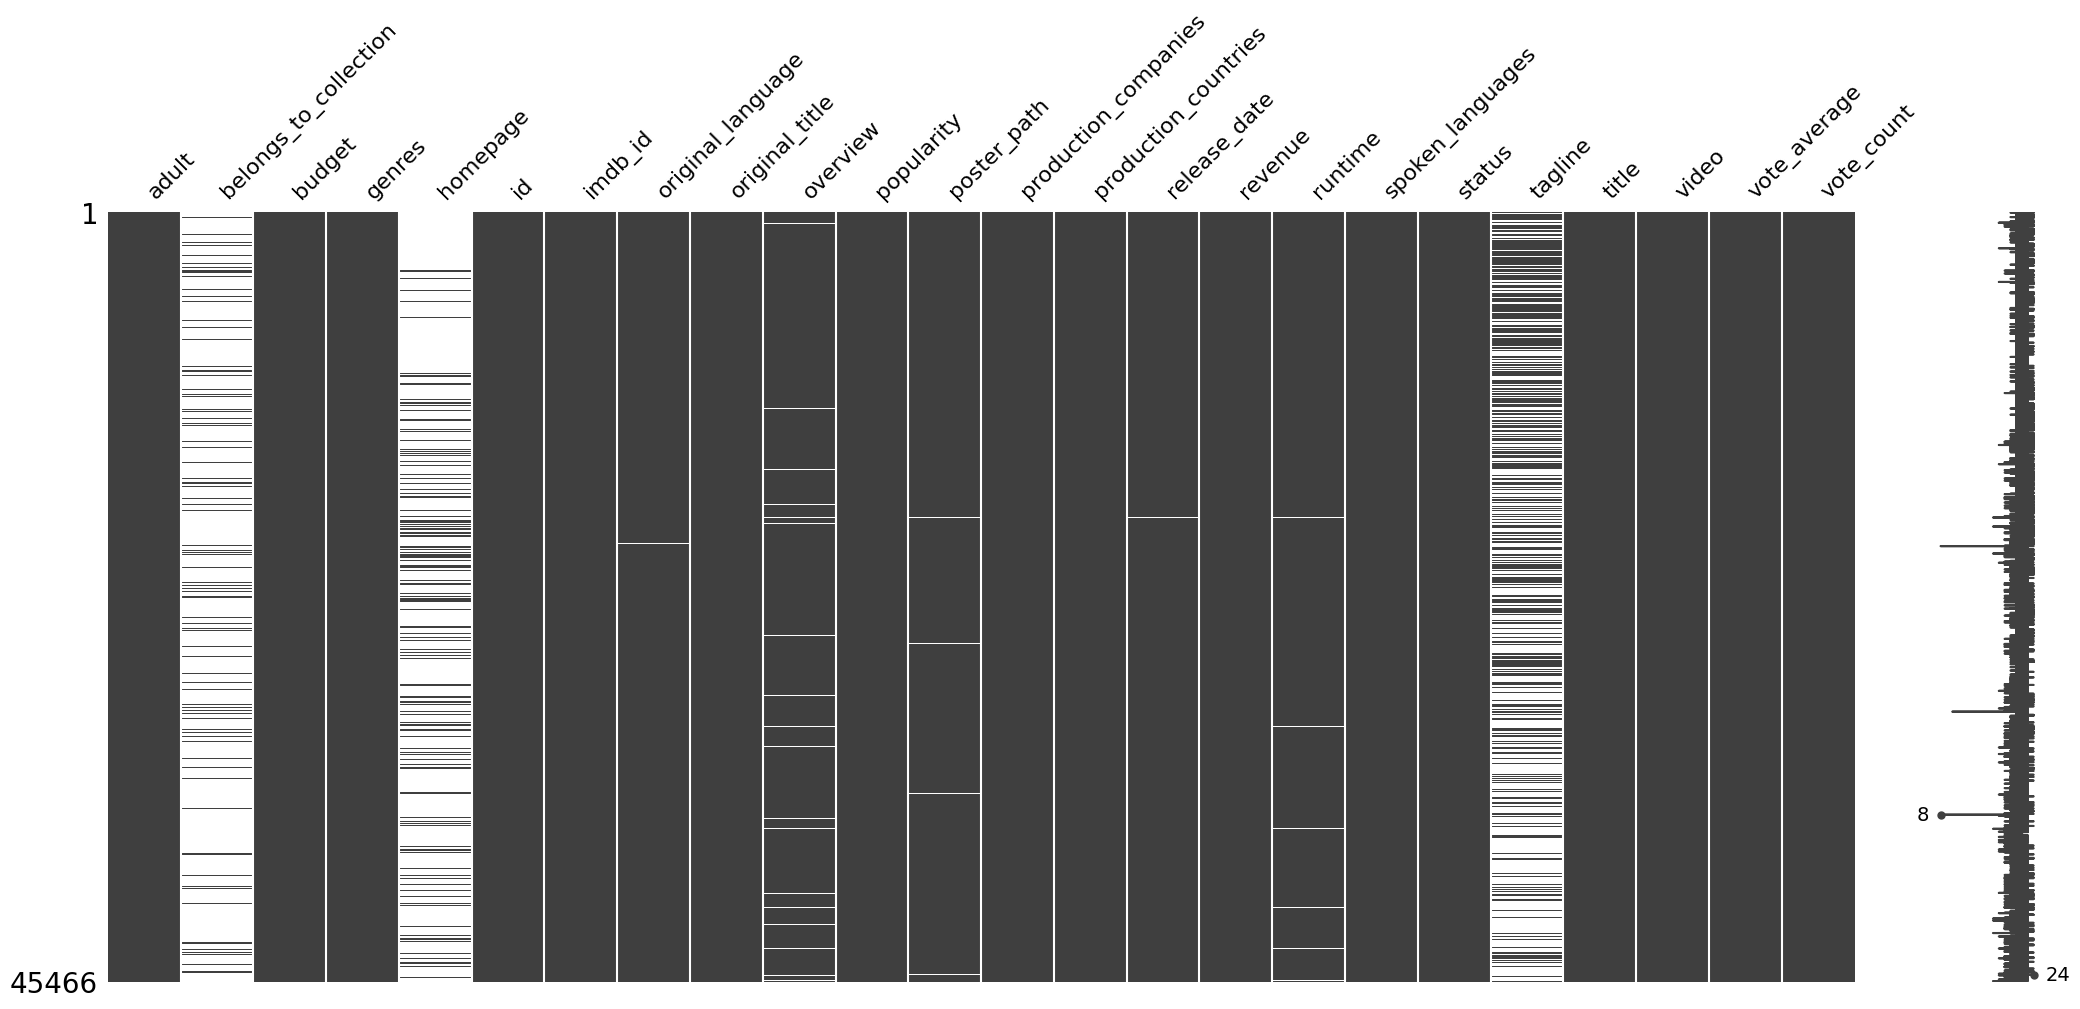

In [6]:
msno.matrix(df)

In [7]:
df.shape

(45466, 24)

In [8]:
print("Missing values in Train DataFrame:")
missing_df = df.isnull().sum().sort_values(ascending=False)
missing_df_percent = (missing_df / len(df)) * 100
missing_df_info = pd.DataFrame({'Missing Count': missing_df, 'Missing Percentage (%)': missing_df_percent})
display(missing_df_info[missing_df_info['Missing Count'] > 0])

Missing values in Train DataFrame:


,Missing Count,Missing Percentage (%)
belongs_to_collection,40972,90.115691
homepage,37684,82.883913
tagline,25054,55.104914
overview,954,2.098271
poster_path,386,0.848986
runtime,263,0.578454
status,87,0.191352
release_date,87,0.191352
imdb_id,17,0.037391
original_language,11,0.024194


# Task
Handle missing values in the `df` DataFrame using best practices.

## Identify handling strategies

### Subtask:
Based on the percentage of missing values and the nature of each column, determine the best approach for handling missing values (e.g., imputation, removal).


**Reasoning**:
Analyze the missing value information and determine the handling strategy for each column based on the percentage of missing values and column nature.



In [9]:
# Analyze missing value percentages from missing_df_info
high_missing_cols = missing_df_info[missing_df_info['Missing Percentage (%)'] > 50].index.tolist()
moderate_missing_cols = missing_df_info[(missing_df_info['Missing Percentage (%)'] <= 50) & (missing_df_info['Missing Percentage (%)'] > 1)].index.tolist()
low_missing_cols = missing_df_info[missing_df_info['Missing Percentage (%)'] <= 1].index.tolist()

print("Columns with high missing percentage (>50%):", high_missing_cols)
print("Columns with moderate missing percentage (1%-50%):", moderate_missing_cols)
print("Columns with low missing percentage (<=1%):", low_missing_cols)

# Determine handling strategy for each column with missing values
handling_strategy = {}

# High missing percentage: Consider dropping
for col in high_missing_cols:
    handling_strategy[col] = "Drop column due to high missing percentage"

# Moderate missing percentage: Consider imputation based on data type
# 'overview' is text, imputation might not be meaningful, could consider dropping or using a placeholder
if 'overview' in moderate_missing_cols:
    handling_strategy['overview'] = "Consider dropping or using a placeholder for text data"

# Low missing percentage: Consider imputation or dropping rows
# For numerical columns like 'runtime', 'vote_average', 'vote_count', 'revenue', 'popularity', consider mean/median imputation
numerical_low_missing = ['runtime', 'vote_average', 'vote_count', 'revenue', 'popularity']
for col in low_missing_cols:
    if col in numerical_low_missing:
        handling_strategy[col] = "Impute with mean or median"
    elif col in ['status', 'release_date', 'imdb_id', 'original_language', 'title', 'video', 'spoken_languages', 'production_countries', 'production_companies', 'poster_path']:
         handling_strategy[col] = "Consider imputation (e.g., mode, placeholder) or dropping rows"


# Special handling for 'adult' column based on previous observation
handling_strategy['adult'] = "Investigate and potentially remove incorrect entries (e.g., 'R')"


print("\nIdentified Handling Strategy for each column with missing values:")
for col, strategy in handling_strategy.items():
    print(f"- {col}: {strategy}")

Columns with high missing percentage (>50%): ['belongs_to_collection', 'homepage', 'tagline']
Columns with moderate missing percentage (1%-50%): ['overview']
Columns with low missing percentage (<=1%): ['poster_path', 'runtime', 'status', 'release_date', 'imdb_id', 'original_language', 'vote_average', 'vote_count', 'title', 'video', 'spoken_languages', 'revenue', 'popularity', 'production_countries', 'production_companies', 'genres', 'id', 'adult', 'budget', 'original_title']

Identified Handling Strategy for each column with missing values:
- belongs_to_collection: Drop column due to high missing percentage
- homepage: Drop column due to high missing percentage
- tagline: Drop column due to high missing percentage
- overview: Consider dropping or using a placeholder for text data
- poster_path: Consider imputation (e.g., mode, placeholder) or dropping rows
- runtime: Impute with mean or median
- status: Consider imputation (e.g., mode, placeholder) or dropping rows
- release_date: Con

In [10]:
# 1. Drop columns with high missing percentages
cols_to_drop = ['belongs_to_collection', 'homepage', 'tagline']
df = df.drop(columns=cols_to_drop)

# 2. Fill missing values in 'overview' with a placeholder
df['overview'] = df['overview'].fillna('No overview available')

# Inspect the 'popularity' column to identify the non-numeric values
print(df['popularity'].dtype)
print(df['popularity'].unique())

# Attempt to convert 'popularity' to numeric, coercing errors
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

# Now retry the imputation for numerical columns
numerical_cols_to_impute = ['runtime', 'vote_average', 'vote_count', 'revenue', 'popularity']
for col in numerical_cols_to_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Fill missing values in remaining columns with low missing percentages with a placeholder
remaining_missing_cols = df.columns[df.isnull().any()].tolist()
cols_to_fill_unknown = [col for col in remaining_missing_cols if col not in numerical_cols_to_impute and col != 'adult']

for col in cols_to_fill_unknown:
    df[col] = df[col].fillna('Unknown')

# Investigate and remove incorrect entries in 'adult' column
df = df[df['adult'].isin(['True', 'False'])]

# Verify that missing values have been handled
print("Missing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

object
[21.946943 17.015539 11.7129 ... '0.903007' '0.003503' '0.163015']
Missing values after handling:


,0
adult,0
budget,0
genres,0
id,0
imdb_id,0
original_language,0
original_title,0
overview,0
popularity,0
poster_path,0


In [11]:
df.shape

(45463, 21)

In [12]:
credits_df = pd.read_csv(credits_path)
keywords_df = pd.read_csv(keywords_path)
links_df = pd.read_csv(links_path)
ratings_df = pd.read_csv(ratings_path)

In [13]:
credits_df.columns

Index(['cast', 'crew', 'id'], dtype='object')

In [14]:
credits_df.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [15]:
credits_df.isnull().sum()

,0
cast,0
crew,0
id,0


In [16]:
keywords_df.columns

Index(['id', 'keywords'], dtype='object')

In [17]:
keywords_df.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [18]:
keywords_df.isnull().sum()

,0
id,0
keywords,0


In [19]:
links_df.columns

Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')

In [20]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [21]:
links_df.isnull().sum()

,0
movieId,0
imdbId,0
tmdbId,219


In [22]:
links_df = links_df.dropna(subset=['tmdbId'])
print("Missing values in links_df after handling:")
display(links_df.isnull().sum())

Missing values in links_df after handling:


,0
movieId,0
imdbId,0
tmdbId,0


In [23]:
ratings_df.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [24]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [25]:
print("Columns of df:", df.columns)
print("Columns of credits_df:", credits_df.columns)
print("Columns of keywords_df:", keywords_df.columns)
print("Columns of links_df:", links_df.columns)
print("Columns of ratings_df:", ratings_df.columns)

Columns of df: Index(['adult', 'budget', 'genres', 'id', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')
Columns of credits_df: Index(['cast', 'crew', 'id'], dtype='object')
Columns of keywords_df: Index(['id', 'keywords'], dtype='object')
Columns of links_df: Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')
Columns of ratings_df: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [26]:
print("Missing values in 'id' column of df:", df['id'].isnull().sum())
print("Missing values in 'id' column of credits_df:", credits_df['id'].isnull().sum())
print("Missing values in 'id' column of keywords_df:", keywords_df['id'].isnull().sum())
print("Missing values in 'tmdbId' column of links_df:", links_df['tmdbId'].isnull().sum())
print("Missing values in 'movieId' column of links_df:", links_df['movieId'].isnull().sum())
print("Missing values in 'movieId' column of ratings_df:", ratings_df['movieId'].isnull().sum())

Missing values in 'id' column of df: 0
Missing values in 'id' column of credits_df: 0
Missing values in 'id' column of keywords_df: 0
Missing values in 'tmdbId' column of links_df: 0
Missing values in 'movieId' column of links_df: 0
Missing values in 'movieId' column of ratings_df: 0


In [27]:
print("Data type of 'id' in df:", df['id'].dtype)
print("Data type of 'id' in credits_df:", credits_df['id'].dtype)
print("Data type of 'id' in keywords_df:", keywords_df['id'].dtype)
print("Data type of 'tmdbId' in links_df:", links_df['tmdbId'].dtype)
print("Data type of 'movieId' in links_df:", links_df['movieId'].dtype)
print("Data type of 'movieId' in ratings_df:", ratings_df['movieId'].dtype)

Data type of 'id' in df: object
Data type of 'id' in credits_df: int64
Data type of 'id' in keywords_df: int64
Data type of 'tmdbId' in links_df: float64
Data type of 'movieId' in links_df: int64
Data type of 'movieId' in ratings_df: int64


In [28]:
df['id'] = pd.to_numeric(df['id'], errors='coerce')
df.dropna(subset=['id'], inplace=True)
df['id'] = df['id'].astype(int)

links_df.dropna(subset=['tmdbId'], inplace=True)
links_df['tmdbId'] = links_df['tmdbId'].astype(int)

print("Updated data type of 'id' in df:", df['id'].dtype)
print("Updated data type of 'tmdbId' in links_df:", links_df['tmdbId'].dtype)

Updated data type of 'id' in df: int64
Updated data type of 'tmdbId' in links_df: int64


In [29]:
df.head().transpose()

,0,1,2,3,4
adult,False,False,False,False,False
budget,30000000,65000000,0,16000000,0
genres,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","[{'id': 35, 'name': 'Comedy'}]"
id,862,8844,15602,31357,11862
imdb_id,tt0114709,tt0113497,tt0113228,tt0114885,tt0113041
original_language,en,en,en,en,en
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...,A family wedding reignites the ancient feud be...,"Cheated on, mistreated and stepped on, the wom...",Just when George Banks has recovered from his ...
popularity,21.946943,17.015539,11.7129,3.859495,8.387519
poster_path,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,/e64sOI48hQXyru7naBFyssKFxVd.jpg


In [30]:
df.shape

(45463, 21)

In [31]:
import json

def is_json_like(value):
    """Checks if a string value is likely a JSON array or object."""
    if isinstance(value, str):
        value = value.strip()
        if (value.startswith('[') and value.endswith(']')) or \
           (value.startswith('{') and value.endswith('}')):
            try:
                json.loads(value)
                return True
            except json.JSONDecodeError:
                pass
    return False

# Identify columns that might contain JSON
json_columns = []
for col in df.columns:
    # Check a sample of non-null values to see if they are json-like
    sample_values = df[col].dropna().sample(min(100, len(df[col].dropna())))
    if any(sample_values.apply(is_json_like)):
        json_columns.append(col)

print("Columns that appear to contain JSON format:", json_columns)

Columns that appear to contain JSON format: ['genres', 'production_companies', 'production_countries', 'spoken_languages']


In [32]:
copy_df = df.copy()

In [33]:
import ast
import numpy as np

def extract_names_and_handle_empty(json_list_string):
    """Extracts names from a string representation of a list of dictionaries and handles empty lists as NaN."""
    if isinstance(json_list_string, str) and json_list_string.startswith('[') and json_list_string.endswith(']'):
        try:
            # Use ast.literal_eval to safely evaluate the string as a Python literal
            data_list = ast.literal_eval(json_list_string)
            if isinstance(data_list, list):
                if not data_list:  # Check if the list is empty
                    return np.nan  # Replace empty list with NaN
                names = [item.get('name', '') for item in data_list if isinstance(item, dict) and 'name' in item]
                return ', '.join(names)
        except (ValueError, SyntaxError):
            pass
    return '' # Return empty string for non-list strings or evaluation errors

# Columns identified as containing JSON format
json_columns = ['genres', 'production_companies', 'production_countries', 'spoken_languages']

# Apply the extraction function and handle empty lists to copy_df
for col in json_columns:
    if col in copy_df.columns:
        copy_df[col] = copy_df[col].apply(extract_names_and_handle_empty)
        # Now fill the NaN values (which were empty lists) with 'Unknown'
        copy_df[col] = copy_df[col].fillna('Unknown')

# Display the head of the modified copy_df DataFrame to confirm
display(copy_df.head().transpose())

,0,1,2,3,4
adult,False,False,False,False,False
budget,30000000,65000000,0,16000000,0
genres,"Animation, Comedy, Family","Adventure, Fantasy, Family","Romance, Comedy","Comedy, Drama, Romance",Comedy
id,862,8844,15602,31357,11862
imdb_id,tt0114709,tt0113497,tt0113228,tt0114885,tt0113041
original_language,en,en,en,en,en
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...,A family wedding reignites the ancient feud be...,"Cheated on, mistreated and stepped on, the wom...",Just when George Banks has recovered from his ...
popularity,21.946943,17.015539,11.7129,3.859495,8.387519
poster_path,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,/e64sOI48hQXyru7naBFyssKFxVd.jpg


In [34]:
parsed_json_columns = ['genres', 'production_companies', 'production_countries', 'spoken_languages']

print("Count and percentage of 'Unknown' values in parsed JSON columns:")
for col in parsed_json_columns:
    if col in copy_df.columns:
        unknown_count = (copy_df[col] == 'Unknown').sum()
        total_count = len(copy_df[col])
        unknown_percentage = (unknown_count / total_count) * 100 if total_count > 0 else 0
        print(f"- {col}: {unknown_count} ('Unknown' values) out of {total_count} (Total values) - {unknown_percentage:.2f}%")

Count and percentage of 'Unknown' values in parsed JSON columns:
- genres: 2442 ('Unknown' values) out of 45463 (Total values) - 5.37%
- production_companies: 11875 ('Unknown' values) out of 45463 (Total values) - 26.12%
- production_countries: 6282 ('Unknown' values) out of 45463 (Total values) - 13.82%
- spoken_languages: 3829 ('Unknown' values) out of 45463 (Total values) - 8.42%


In [35]:
df = copy_df.copy()

In [36]:
import json

def is_json_like(value):
    """Checks if a string value is likely a JSON array or object."""
    if isinstance(value, str):
        value = value.strip()
        if (value.startswith('[') and value.endswith(']')) or \
           (value.startswith('{') and value.endswith('}')):
            try:
                json.loads(value)
                return True
            except json.JSONDecodeError:
                pass
    return False

# Identify columns that might contain JSON in credits_df
json_columns_credits = []
for col in credits_df.columns:
    # Check a sample of non-null values to see if they are json-like
    sample_values = credits_df[col].dropna().sample(min(100, len(credits_df[col].dropna())))
    if any(sample_values.apply(is_json_like)):
        json_columns_credits.append(col)

print("Columns in credits_df that appear to contain JSON format:", json_columns_credits)

# Identify columns that might contain JSON in keywords_df
json_columns_keywords = []
for col in keywords_df.columns:
    # Check a sample of non-null values to see if they are json-like
    sample_values = keywords_df[col].dropna().sample(min(100, len(keywords_df[col].dropna())))
    if any(sample_values.apply(is_json_like)):
        json_columns_keywords.append(col)

print("Columns in keywords_df that appear to contain JSON format:", json_columns_keywords)

Columns in credits_df that appear to contain JSON format: ['cast', 'crew']
Columns in keywords_df that appear to contain JSON format: ['keywords']


In [37]:
import ast
import numpy as np

def extract_names_from_list(json_list_string, key='name'):
    """Extracts values for a given key from a string representation of a list of dictionaries and handles empty lists as NaN."""
    if isinstance(json_list_string, str) and json_list_string.startswith('[') and json_list_string.endswith(']'):
        try:
            data_list = ast.literal_eval(json_list_string)
            if isinstance(data_list, list):
                if not data_list:  # Check if the list is empty
                    return np.nan  # Replace empty list with NaN
                names = [item.get(key, '') for item in data_list if isinstance(item, dict) and key in item]
                return ', '.join(names)
        except (ValueError, SyntaxError):
            pass
    return '' # Return empty string for non-list strings or evaluation errors

# Handle JSON columns in credits_df
# 'cast' and 'crew' columns contain lists of dictionaries, we'll extract names
credits_df['cast'] = credits_df['cast'].apply(extract_names_from_list, key='name')
credits_df['crew'] = credits_df['crew'].apply(extract_names_from_list, key='name')

# Fill NaN values (originally empty lists) with 'Unknown' in credits_df
credits_df['cast'] = credits_df['cast'].fillna('Unknown')
credits_df['crew'] = credits_df['crew'].fillna('Unknown')

# Handle JSON columns in keywords_df
# 'keywords' column contains a list of dictionaries, we'll extract names
keywords_df['keywords'] = keywords_df['keywords'].apply(extract_names_from_list, key='name')

# Fill NaN values (originally empty lists) with 'Unknown' in keywords_df
keywords_df['keywords'] = keywords_df['keywords'].fillna('Unknown')


print("credits_df after parsing and handling empty lists:")
display(credits_df.head())

print("\nkeywords_df after parsing and handling empty lists:")
display(keywords_df.head())

credits_df after parsing and handling empty lists:


,cast,crew,id
0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...","John Lasseter, Joss Whedon, Andrew Stanton, Jo...",862
1,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...","Larry J. Franco, Jonathan Hensleigh, James Hor...",8844
2,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...","Howard Deutch, Mark Steven Johnson, Mark Steve...",15602
3,"Whitney Houston, Angela Bassett, Loretta Devin...","Forest Whitaker, Ronald Bass, Ronald Bass, Ezr...",31357
4,"Steve Martin, Diane Keaton, Martin Short, Kimb...","Alan Silvestri, Elliot Davis, Nancy Meyers, Na...",11862



keywords_df after parsing and handling empty lists:


,id,keywords
0,862,"jealousy, toy, boy, friendship, friends, rival..."
1,8844,"board game, disappearance, based on children's..."
2,15602,"fishing, best friend, duringcreditsstinger, ol..."
3,31357,"based on novel, interracial relationship, sing..."
4,11862,"baby, midlife crisis, confidence, aging, daugh..."


In [38]:
# Columns in credits_df and keywords_df where empty lists were replaced by 'Unknown'
parsed_credits_columns = ['cast', 'crew']
parsed_keywords_columns = ['keywords']

print("Count and percentage of 'Unknown' values in parsed credits_df columns:")
for col in parsed_credits_columns:
    if col in credits_df.columns:
        unknown_count = (credits_df[col] == 'Unknown').sum()
        total_count = len(credits_df[col])
        unknown_percentage = (unknown_count / total_count) * 100 if total_count > 0 else 0
        print(f"- {col}: {unknown_count} ('Unknown' values) out of {total_count} (Total values) - {unknown_percentage:.2f}%")

print("\nCount and percentage of 'Unknown' values in parsed keywords_df columns:")
for col in parsed_keywords_columns:
    if col in keywords_df.columns:
        unknown_count = (keywords_df[col] == 'Unknown').sum()
        total_count = len(keywords_df[col])
        unknown_percentage = (unknown_count / total_count) * 100 if total_count > 0 else 0
        print(f"- {col}: {unknown_count} ('Unknown' values) out of {total_count} (Total values) - {unknown_percentage:.2f}%")

Count and percentage of 'Unknown' values in parsed credits_df columns:
- cast: 2418 ('Unknown' values) out of 45476 (Total values) - 5.32%
- crew: 771 ('Unknown' values) out of 45476 (Total values) - 1.70%

Count and percentage of 'Unknown' values in parsed keywords_df columns:
- keywords: 14795 ('Unknown' values) out of 46419 (Total values) - 31.87%


In [39]:
df.head().transpose()

,0,1,2,3,4
adult,False,False,False,False,False
budget,30000000,65000000,0,16000000,0
genres,"Animation, Comedy, Family","Adventure, Fantasy, Family","Romance, Comedy","Comedy, Drama, Romance",Comedy
id,862,8844,15602,31357,11862
imdb_id,tt0114709,tt0113497,tt0113228,tt0114885,tt0113041
original_language,en,en,en,en,en
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...,A family wedding reignites the ancient feud be...,"Cheated on, mistreated and stepped on, the wom...",Just when George Banks has recovered from his ...
popularity,21.946943,17.015539,11.7129,3.859495,8.387519
poster_path,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,/e64sOI48hQXyru7naBFyssKFxVd.jpg


In [40]:
# Check for duplicates in the key columns
print("Duplicates in 'id' column of df:", df['id'].duplicated().sum())
print("Duplicates in 'id' column of credits_df:", credits_df['id'].duplicated().sum())
print("Duplicates in 'id' column of keywords_df:", keywords_df['id'].duplicated().sum())
print("Duplicates in 'tmdbId' column of links_df:", links_df['tmdbId'].duplicated().sum())
print("Duplicates in 'movieId' column of links_df:", links_df['movieId'].duplicated().sum())
print("Duplicates in 'movieId' column of ratings_df:", ratings_df['movieId'].duplicated().sum())

Duplicates in 'id' column of df: 30
Duplicates in 'id' column of credits_df: 44
Duplicates in 'id' column of keywords_df: 987
Duplicates in 'tmdbId' column of links_df: 30
Duplicates in 'movieId' column of links_df: 0
Duplicates in 'movieId' column of ratings_df: 25979174


In [41]:
# Remove duplicates from key columns
df.drop_duplicates(subset=['id'], inplace=True)
credits_df.drop_duplicates(subset=['id'], inplace=True)
keywords_df.drop_duplicates(subset=['id'], inplace=True)
ratings_df.drop_duplicates(subset=['movieId'], inplace=True)

print("Duplicates in 'id' column of df after removal:", df['id'].duplicated().sum())
print("Duplicates in 'id' column of credits_df after removal:", credits_df['id'].duplicated().sum())
print("Duplicates in 'id' column of keywords_df after removal:", keywords_df['id'].duplicated().sum())
print("Duplicates in 'tmdbId' column of links_df after removal:", links_df['tmdbId'].duplicated().sum()) # Re-checking for completeness
print("Duplicates in 'movieId' column of links_df after removal:", links_df['movieId'].duplicated().sum()) # Re-checking for completeness
print("Duplicates in 'movieId' column of ratings_df after removal:", ratings_df['movieId'].duplicated().sum())

Duplicates in 'id' column of df after removal: 0
Duplicates in 'id' column of credits_df after removal: 0
Duplicates in 'id' column of keywords_df after removal: 0
Duplicates in 'tmdbId' column of links_df after removal: 30
Duplicates in 'movieId' column of links_df after removal: 0
Duplicates in 'movieId' column of ratings_df after removal: 0


In [42]:
print("Shape of df:", df.shape)
print("Shape of credits_df:", credits_df.shape)
print("Shape of keywords_df:", keywords_df.shape)
print("Shape of links_df:", links_df.shape)
print("Shape of ratings_df:", ratings_df.shape)

Shape of df: (45433, 21)
Shape of credits_df: (45432, 3)
Shape of keywords_df: (45432, 2)
Shape of links_df: (45624, 3)
Shape of ratings_df: (45115, 4)


In [43]:
# Merge df, credits_df, and keywords_df on 'id'
merged_df = pd.merge(df, credits_df, on='id', how='inner')
merged_df = pd.merge(merged_df, keywords_df, on='id', how='inner')

# Merge with links_df using tmdbId from links_df and id from merged_df
# links_df has 'movieId' (MovieLens ID) and 'tmdbId' (TMDB ID)
merged_df = pd.merge(merged_df, links_df, left_on='id', right_on='tmdbId', how='inner')

# Now merge the result with ratings_df using movieId (MovieLens ID)
merged_df = pd.merge(merged_df, ratings_df, on='movieId', how='inner')

print("Shape of the merged dataframe:", merged_df.shape)
display(merged_df.head().transpose())

Shape of the merged dataframe: (44740, 30)


,0,1,2,3,4
adult,False,False,False,False,False
budget,30000000,65000000,0,16000000,0
genres,"Animation, Comedy, Family","Adventure, Fantasy, Family","Romance, Comedy","Comedy, Drama, Romance",Comedy
id,862,8844,15602,31357,11862
imdb_id,tt0114709,tt0113497,tt0113228,tt0114885,tt0113041
original_language,en,en,en,en,en
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...,A family wedding reignites the ancient feud be...,"Cheated on, mistreated and stepped on, the wom...",Just when George Banks has recovered from his ...
popularity,21.946943,17.015539,11.7129,3.859495,8.387519
poster_path,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,/e64sOI48hQXyru7naBFyssKFxVd.jpg


In [44]:
merged_df.shape

(44740, 30)

In [45]:
# Drop redundant ID columns
merged_df = merged_df.drop(columns=['id', 'tmdbId', 'imdbId'])

# Define the desired column order
desired_column_order = [
    'movieId',
    'title',
    'original_title',
    'release_date',
    'runtime',
    'status',
    'adult',
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'vote_count',
    'overview',
    'genres',
    'keywords',
    'cast',
    'crew',
    'production_companies',
    'production_countries',
    'spoken_languages',
    'userId',
    'rating',
    'timestamp'
]

# Reindex the DataFrame with the desired column order
merged_df = merged_df.reindex(columns=desired_column_order)

print("Shape of merged_df after dropping columns and reordering:", merged_df.shape)
display(merged_df.head().transpose())

Shape of merged_df after dropping columns and reordering: (44740, 23)


,0,1,2,3,4
movieId,1,2,3,4,5
title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
release_date,1995-10-30,1995-12-15,1995-12-22,1995-12-22,1995-02-10
runtime,81.0,104.0,101.0,127.0,106.0
status,Released,Released,Released,Released,Released
adult,False,False,False,False,False
budget,30000000,65000000,0,16000000,0
revenue,373554033.0,262797249.0,0.0,81452156.0,76578911.0
popularity,21.946943,17.015539,11.7129,3.859495,8.387519


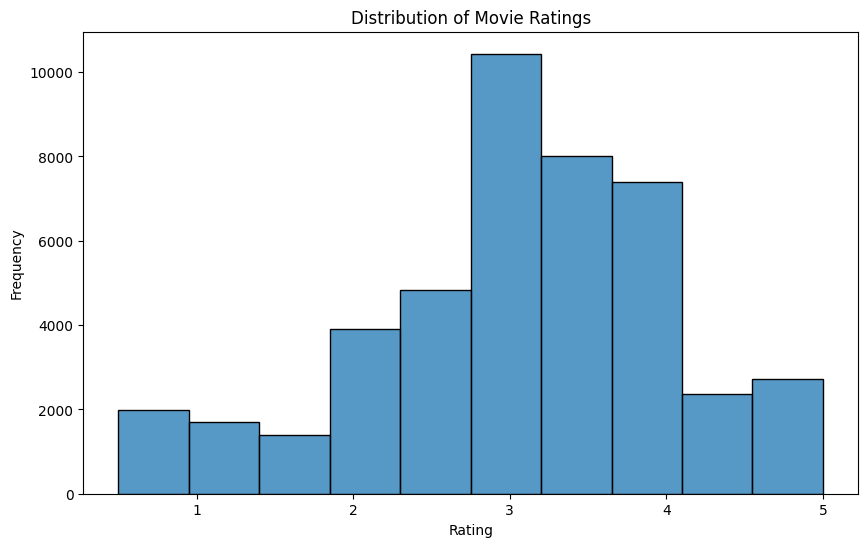

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['rating'], bins=10, kde=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

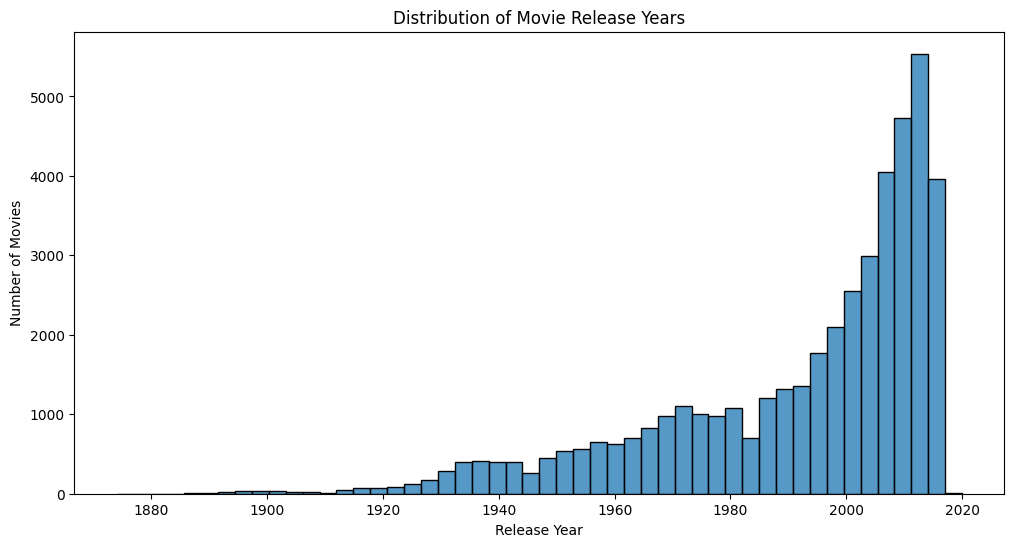

In [47]:
# Convert 'release_date' to datetime objects, coercing errors to NaT
merged_df['release_date'] = pd.to_datetime(merged_df['release_date'], errors='coerce')

# Extract the year from 'release_date'
merged_df['release_year'] = merged_df['release_date'].dt.year

# Create a histogram of the 'release_year' column
plt.figure(figsize=(12, 6))
sns.histplot(merged_df['release_year'].dropna(), bins=50, kde=False)
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.show()

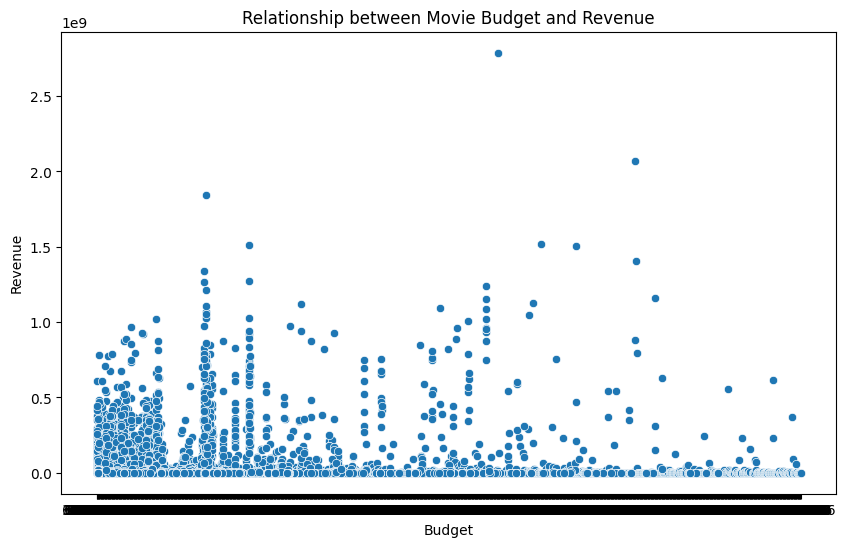

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='budget', y='revenue')
plt.title('Relationship between Movie Budget and Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

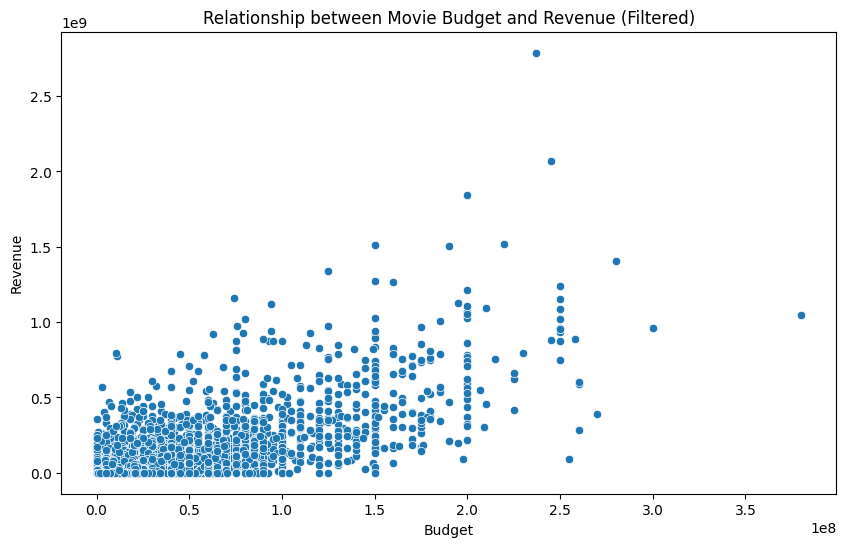

In [49]:
# Convert 'budget' and 'revenue' to numeric, coercing errors to NaN
merged_df['budget'] = pd.to_numeric(merged_df['budget'], errors='coerce')
merged_df['revenue'] = pd.to_numeric(merged_df['revenue'], errors='coerce')

# Fill NaN values in 'budget' and 'revenue' with 0, as 0 budget/revenue is a meaningful value
merged_df['budget'] = merged_df['budget'].fillna(0)
merged_df['revenue'] = merged_df['revenue'].fillna(0)

# Filter out movies with zero budget AND zero revenue
filtered_df = merged_df[(merged_df['budget'] > 0) | (merged_df['revenue'] > 0)].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_df, x='budget', y='revenue')
plt.title('Relationship between Movie Budget and Revenue (Filtered)')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

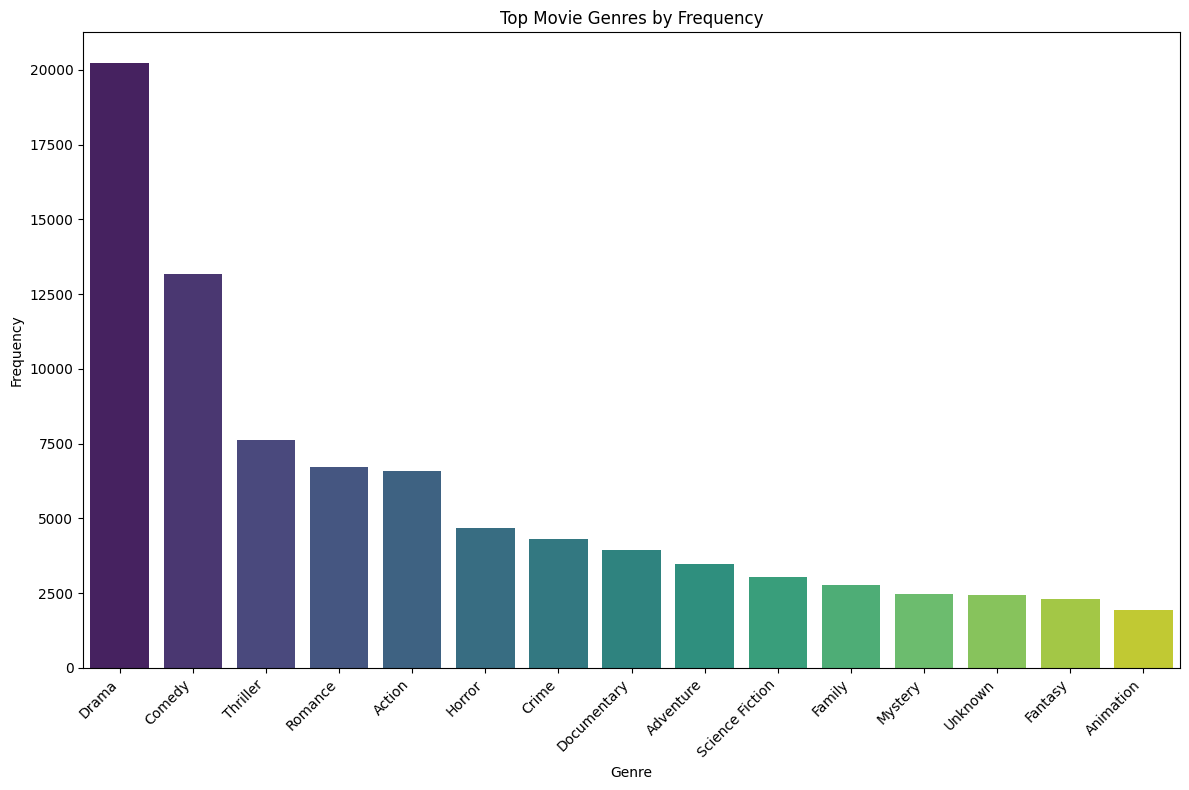

In [50]:
# Count genre occurrences
genre_counts = {}
for genres_list in df['genres'].dropna():
    if isinstance(genres_list, str):
        genres = [genre.strip() for genre in genres_list.split(',')]
        for genre in genres:
            if genre: # Avoid counting empty strings if any
                genre_counts[genre] = genre_counts.get(genre, 0) + 1

# Select top N genres
top_n = 15
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(top_n)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.title('Top Movie Genres by Frequency')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

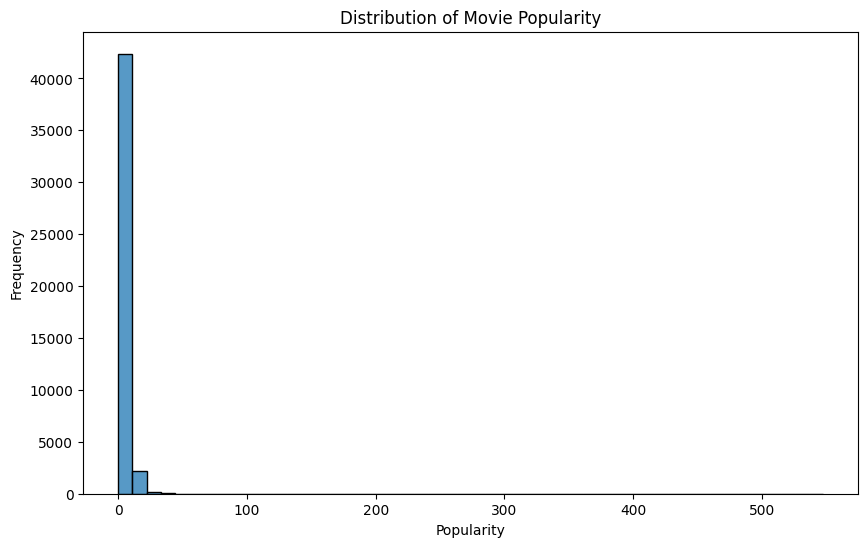

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['popularity'], bins=50, kde=False)
plt.title('Distribution of Movie Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

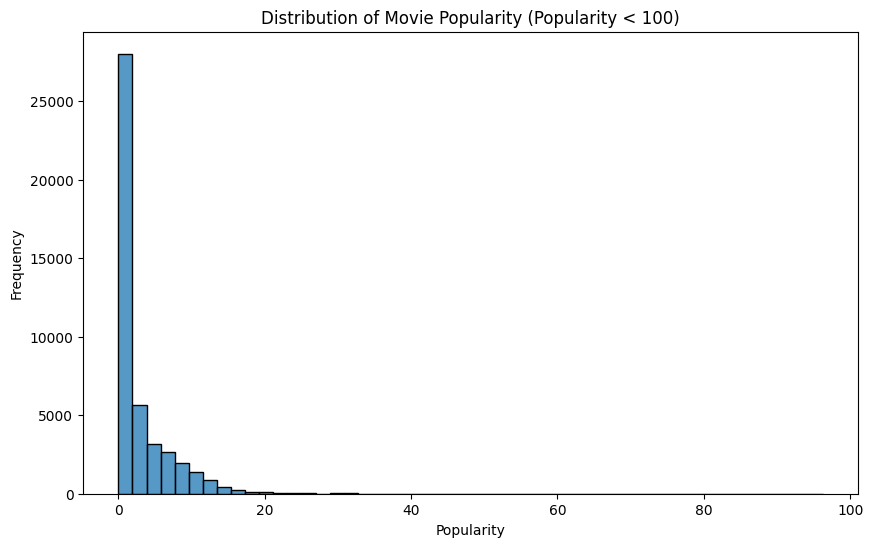

In [52]:
filtered_popularity_df = merged_df[merged_df['popularity'] < 100].copy()

plt.figure(figsize=(10, 6))
sns.histplot(filtered_popularity_df['popularity'], bins=50, kde=False)
plt.title('Distribution of Movie Popularity (Popularity < 100)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

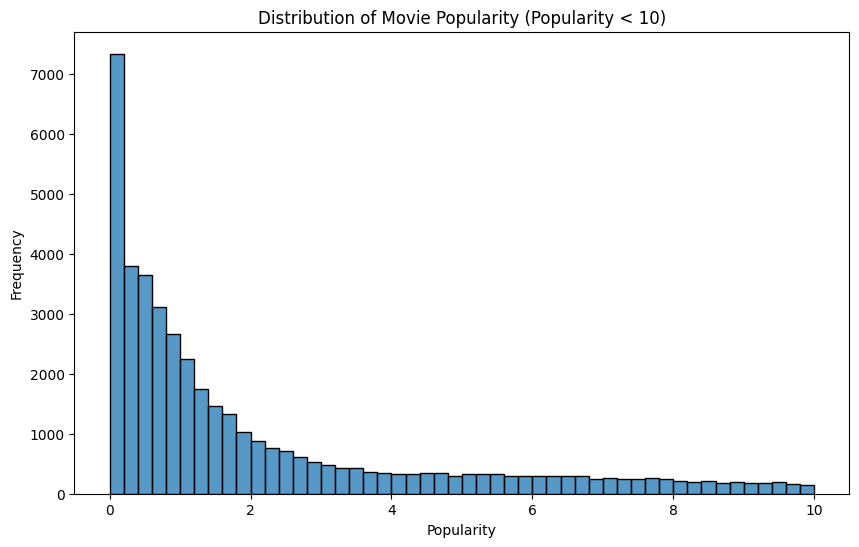

In [53]:
filtered_popularity_df_low = merged_df[merged_df['popularity'] < 10].copy()

plt.figure(figsize=(10, 6))
sns.histplot(filtered_popularity_df_low['popularity'], bins=50, kde=False)
plt.title('Distribution of Movie Popularity (Popularity < 10)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

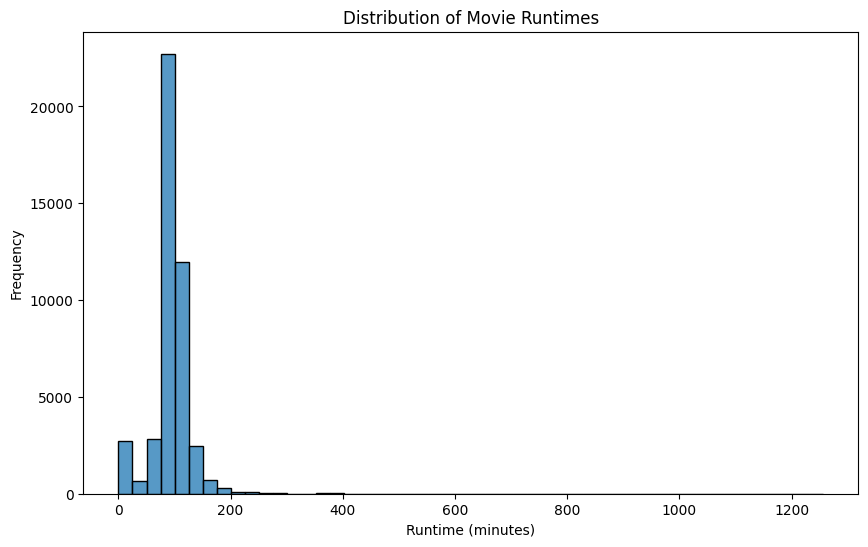

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['runtime'].dropna(), bins=50, kde=False)
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.show()

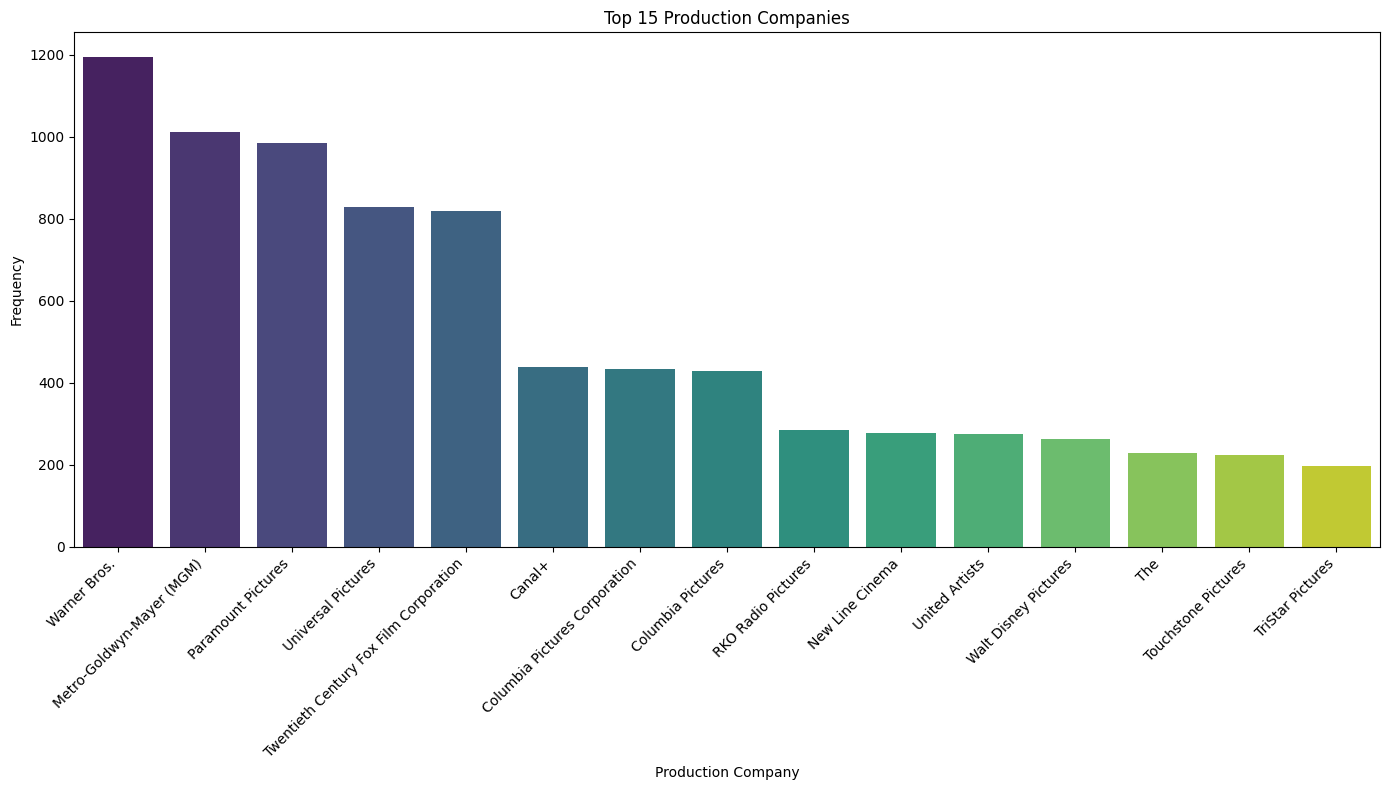

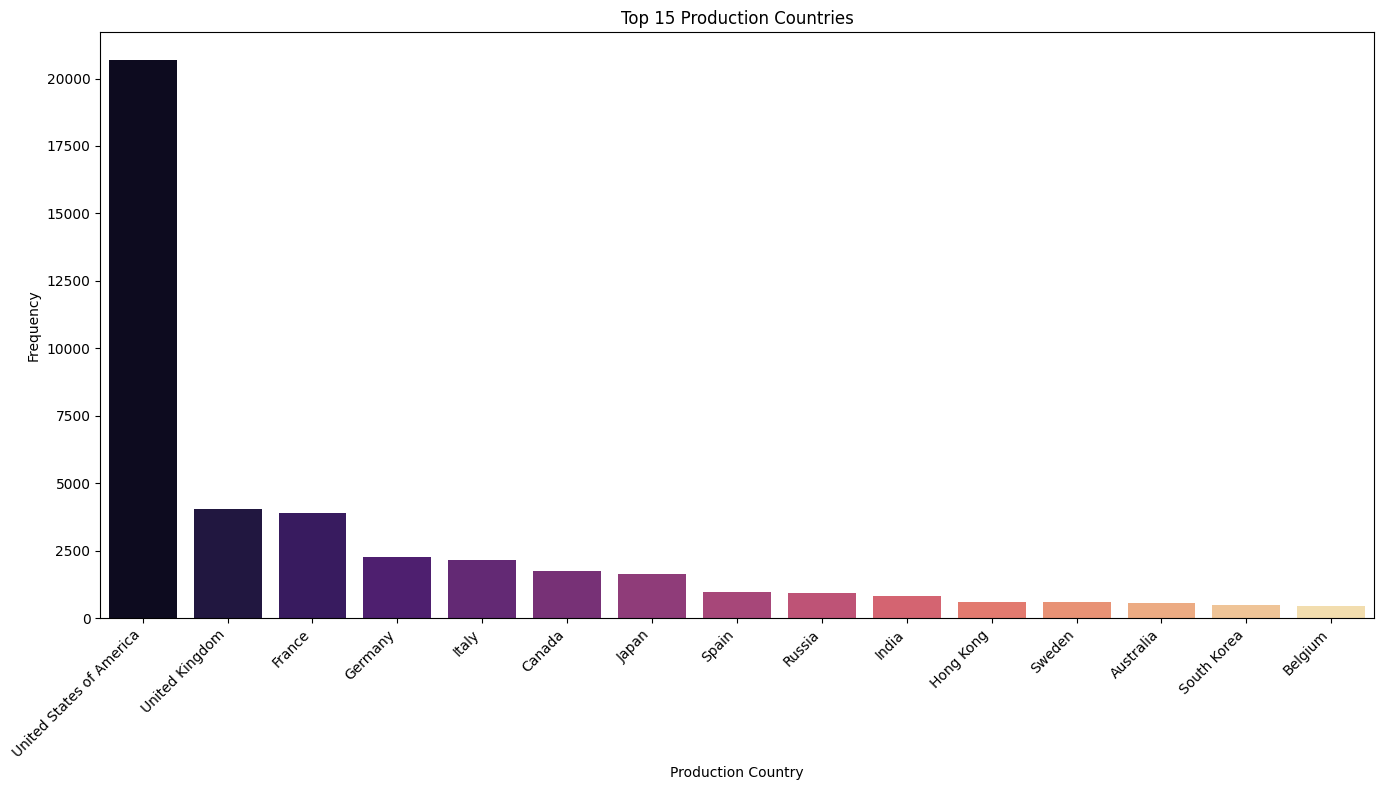

In [55]:
# 1. Count production company occurrences
company_counts = {}
for companies_list in merged_df['production_companies'].dropna():
    if isinstance(companies_list, str):
        companies = [company.strip() for company in companies_list.split(',')]
        for company in companies:
            if company and company != 'Unknown': # Avoid counting empty strings and 'Unknown'
                company_counts[company] = company_counts.get(company, 0) + 1

# 2. Select the top 15 production companies
top_n_companies = 15
top_companies = pd.Series(company_counts).sort_values(ascending=False).head(top_n_companies)

# 3. Create a bar plot of the top 15 production companies
plt.figure(figsize=(14, 8))
sns.barplot(x=top_companies.index, y=top_companies.values, palette='viridis')
# 4. Add title and labels
plt.title(f'Top {top_n_companies} Production Companies')
plt.xlabel('Production Company')
plt.ylabel('Frequency')
# 5. Rotate x-axis labels and adjust layout
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# 6. Display the plot
plt.show()

# 7. Repeat for production countries
country_counts = {}
for countries_list in merged_df['production_countries'].dropna():
    if isinstance(countries_list, str):
        countries = [country.strip() for country in countries_list.split(',')]
        for country in countries:
            if country and country != 'Unknown': # Avoid counting empty strings and 'Unknown'
                country_counts[country] = country_counts.get(country, 0) + 1

# Select the top 15 production countries
top_n_countries = 15
top_countries = pd.Series(country_counts).sort_values(ascending=False).head(top_n_countries)

# Create a bar plot of the top 15 production countries
plt.figure(figsize=(14, 8))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')
# Add title and labels
plt.title(f'Top {top_n_countries} Production Countries')
plt.xlabel('Production Country')
plt.ylabel('Frequency')
# Rotate x-axis labels and adjust layout
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Display the plot
plt.show()

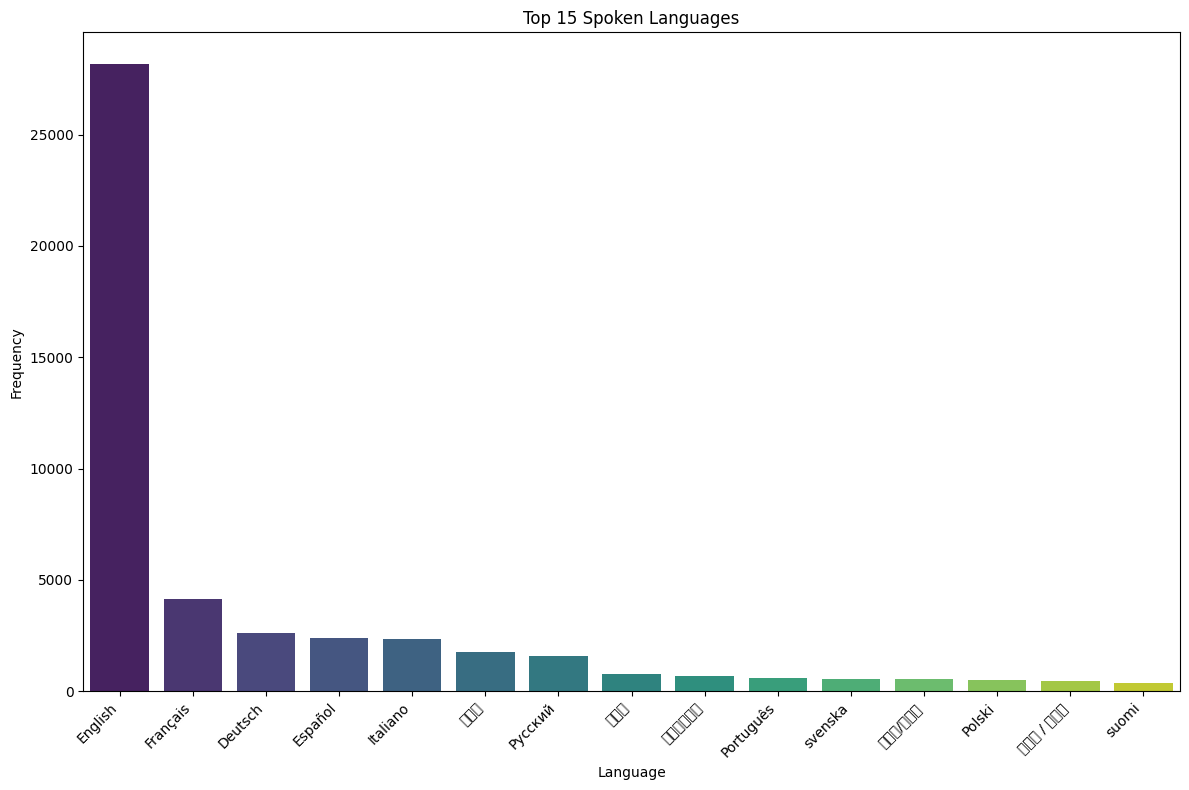

In [56]:
# 1. Create an empty dictionary called language_counts.
language_counts = {}

# 2. Iterate through the spoken_languages column of the merged_df DataFrame.
for languages_list in merged_df['spoken_languages'].dropna():
    # 3. For each entry, check if it's a non-null string.
    if isinstance(languages_list, str):
        # 4. Split the string by comma and iterate through the resulting list of languages.
        languages = [lang.strip() for lang in languages_list.split(',')]
        for lang in languages:
            # 5. For each language, strip leading/trailing whitespace and check if it's not an empty string or 'Unknown'.
            if lang and lang != 'Unknown':
                # 6. Increment the count for the language in the language_counts dictionary.
                language_counts[lang] = language_counts.get(lang, 0) + 1

# 7. Convert the language_counts dictionary to a pandas Series and sort it in descending order.
language_counts_series = pd.Series(language_counts).sort_values(ascending=False)

# 8. Select the top 15 languages.
top_languages = language_counts_series.head(15)

# 9. Create a bar plot of the top 15 spoken languages using seaborn's barplot.
plt.figure(figsize=(12, 8))
sns.barplot(x=top_languages.index, y=top_languages.values, palette='viridis')

# 10. Set the title of the plot to 'Top 15 Spoken Languages'.
plt.title('Top 15 Spoken Languages')

# 11. Set the x-axis label to 'Language' and the y-axis label to 'Frequency'.
plt.xlabel('Language')
plt.ylabel('Frequency')

# 12. Rotate the x-axis labels by 45 degrees for better readability and align them to the right.
plt.xticks(rotation=45, ha='right')

# 13. Adjust the plot layout to prevent labels overlapping.
plt.tight_layout()

# 14. Display the plot.
plt.show()

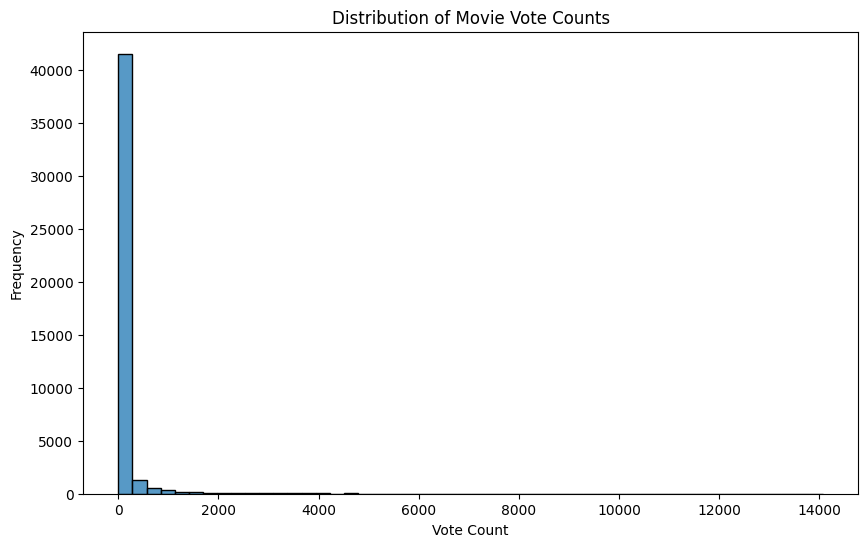

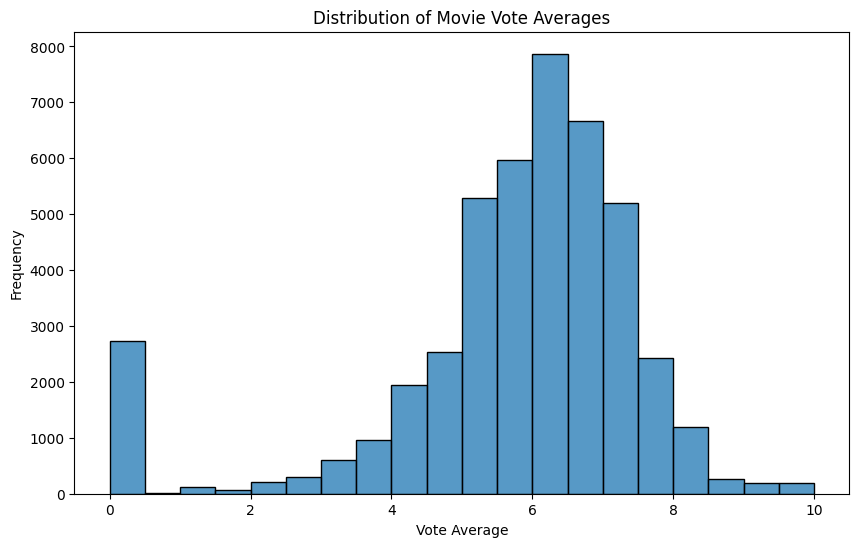

In [57]:
# Create a histogram for the 'vote_count' column
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['vote_count'], bins=50, kde=False)
plt.title('Distribution of Movie Vote Counts')
plt.xlabel('Vote Count')
plt.ylabel('Frequency')
plt.show()

# Create a histogram for the 'vote_average' column
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['vote_average'], bins=20, kde=False) # Using fewer bins for average
plt.title('Distribution of Movie Vote Averages')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.show()

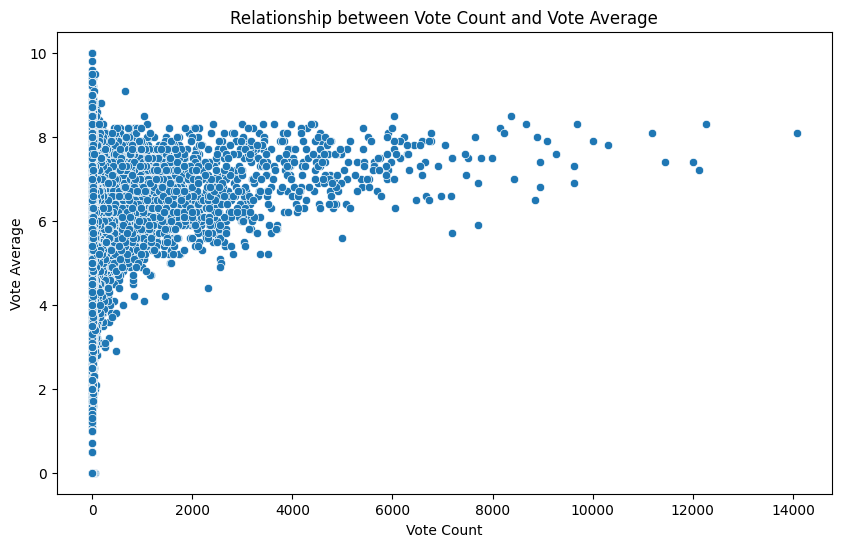

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='vote_count', y='vote_average')
plt.title('Relationship between Vote Count and Vote Average')
plt.xlabel('Vote Count')
plt.ylabel('Vote Average')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The distribution of movie ratings is concentrated around higher values.
*   The number of movie releases has increased significantly over the years, with a peak in recent decades.
*   There is a visible positive correlation between movie budget and revenue, although many movies have zero reported budget and/or revenue.
*   "Drama" is the most frequent movie genre in the dataset, followed by "Comedy" and "Thriller".
*   The distribution of movie popularity is heavily skewed, with a large number of movies having very low popularity scores.
*   Movie runtimes show a distribution with a peak around 90-120 minutes.
*   "Warner Bros.", "Universal Pictures", and "Paramount Pictures" are among the most frequent production companies.
*   The "United States of America" is by far the most frequent production country.
*   "English" is the most frequent spoken language, significantly more common than other languages.
*   The distribution of vote counts is heavily skewed towards lower values, while the distribution of vote averages is more spread out, peaking at higher average values.
*   The scatter plot of vote count versus vote average suggests that movies with higher vote counts tend to have higher average ratings, although there is significant variability.

### Insights or Next Steps

*   The skewed distributions of popularity and vote count indicate that standard statistical analyses might need transformation or non-parametric methods.
*   Further investigation into movies with zero budget/revenue is needed to understand data completeness and potentially impute missing values if necessary for financial analysis.


In [59]:
from wordcloud import WordCloud, STOPWORDS

In [60]:
copy = df.copy()

In [61]:
copy['title'] = copy['title'].astype('str')
copy['overview'] = copy['overview'].astype('str')

In [62]:
title_corpus = ' '.join(copy['title'])
overview_corpus = ' '.join(copy['overview'])

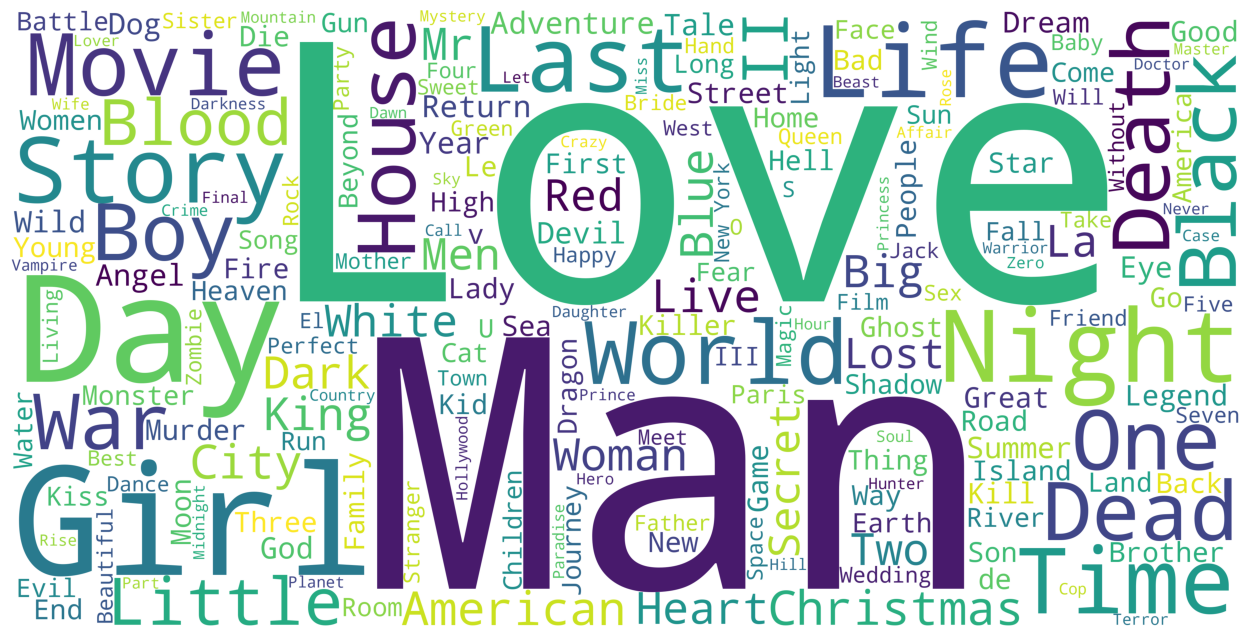

In [63]:
title_wordcloud = WordCloud(stopwords=STOPWORDS, background_color='white', height=2000, width=4000).generate(title_corpus)
plt.figure(figsize=(16,8))
plt.imshow(title_wordcloud)
plt.axis('off')
plt.show()

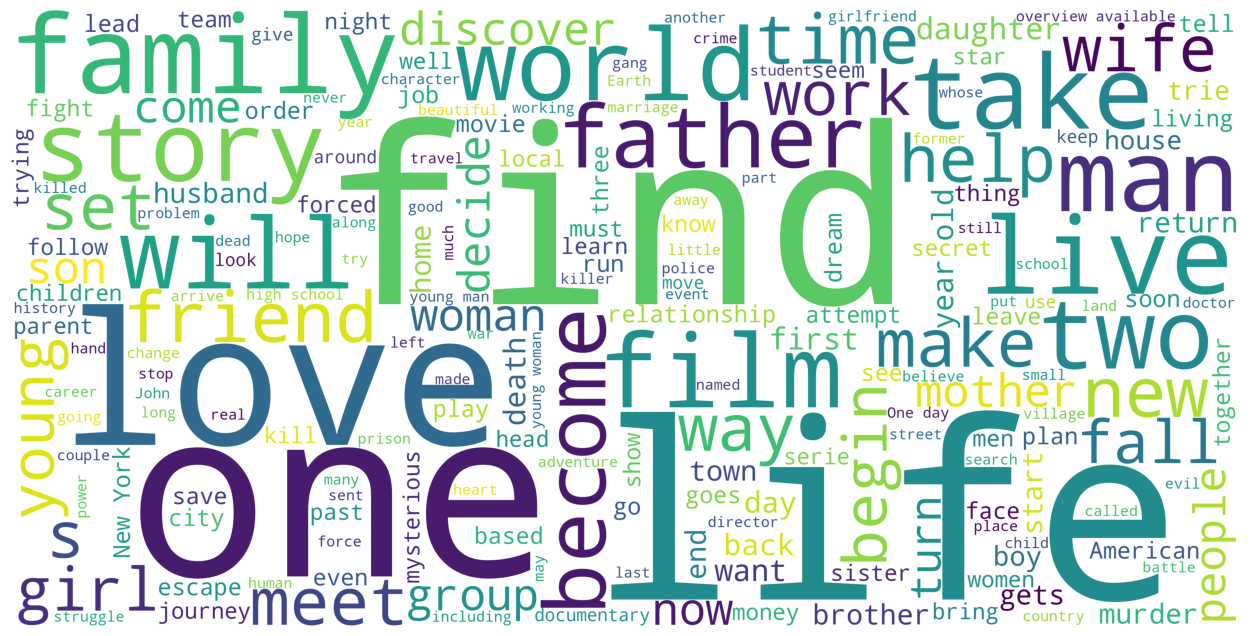

In [64]:
overview_wordcloud = WordCloud(stopwords=STOPWORDS, background_color='white', height=2000, width=4000).generate(overview_corpus)
plt.figure(figsize=(16,8))
plt.imshow(overview_wordcloud)
plt.axis('off')
plt.show()

In [65]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 28.7 MB/s eta 0:00:00


In [66]:
import pandas as pd
import plotly.graph_objs as go
import plotly.offline as py
import pycountry

def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

country_counts = copy['production_countries'].value_counts().reset_index()
country_counts.columns = ['country', 'num_movies']

country_counts = country_counts[country_counts['country'] != "United States of America"]

country_counts['iso_alpha'] = country_counts['country'].apply(get_iso3)

country_counts = country_counts.dropna(subset=['iso_alpha'])

data = [go.Choropleth(
    locations = country_counts['iso_alpha'],
    z = country_counts['num_movies'],
    text = country_counts['country'],
    colorscale = [[0,'rgb(255,255,255)'], [1,'rgb(255,0,0)']],
    autocolorscale = False,
    reversescale = False,
    marker = dict(
        line = dict(color='rgb(180,180,180)', width=0.5)
    ),
    colorbar = dict(title='Production Countries')
)]

layout = dict(
    title = 'Production Countries for the MovieLens Movies (Apart from US)',
    geo = dict(
        showframe = False,
        showcoastlines = False,
        projection = dict(type = 'Mercator')
    )
)

fig = dict(data=data, layout=layout)
py.iplot(fig, validate=False, filename='world-map')


In [67]:
copy.columns

Index(['adult', 'budget', 'genres', 'id', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [68]:
import pandas as pd
import plotly.express as px

# Ensure release_date is datetime
copy['release_date'] = pd.to_datetime(copy['release_date'], errors='coerce')

# Extract decade
copy['decade'] = (copy['release_date'].dt.year // 10) * 10

# Count movies per decade
decade_counts = copy['decade'].value_counts().sort_index().reset_index()
decade_counts.columns = ['decade', 'num_movies']

# Convert decade to string labels
decade_counts['decade'] = decade_counts['decade'].astype(int).astype(str) + "s"

# Plot pie chart with different colors
fig = px.pie(
    decade_counts,
    names='decade',
    values='num_movies',
    title="Movies Distribution by Decade (Release Date)",
    color_discrete_sequence=px.colors.qualitative.Set3   # colorful palette
)

fig.show()

In [73]:
merged_df.columns

Index(['movieId', 'title', 'original_title', 'release_date', 'runtime',
       'status', 'adult', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'overview', 'genres', 'keywords', 'cast', 'crew',
       'production_companies', 'production_countries', 'spoken_languages',
       'userId', 'rating', 'timestamp', 'release_year'],
      dtype='object')